# 1D CNN Model Development

This section focuses on developing a **one-dimensional Convolutional Neural Network (1D CNN)** for phishing URL classification.

While the project also includes an MLP-based model developed separately, this notebook focuses specifically on the CNN architecture and its ability to learn patterns from the input features.

## Objective

The objective is to build and train a 1D CNN model that can classify URLs into their respective classes based on the extracted numerical features.

## Model Architecture

The CNN model consists of the following main components:

* **Input Layer** – Receives the prepared numerical feature data.
* **1D Convolutional Layer** – Extracts local patterns and relationships between neighboring input features.
* **Max Pooling Layer** – Reduces the dimensionality of the extracted feature representations while retaining important information.
* **Flatten Layer** – Converts the extracted feature maps into a one-dimensional vector.
* **Dense Layer** – Learns higher-level representations from the extracted features.
* **Dropout Layer** – Helps reduce overfitting during training.
* **Output Layer** – Produces the final classification prediction.

## Training Approach

The model is trained using the prepared training dataset and evaluated on unseen data. **Early stopping** is used during training to monitor model performance and help prevent unnecessary training once the validation performance stops improving.

The trained CNN model will subsequently be evaluated using classification metrics and visualizations such as:

* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC
* Confusion Matrix
* ROC Curve
* Training and validation performance


In [19]:
import sys
from pathlib import Path

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report

# Project root
PROJECT_ROOT = Path.cwd().parent

# Allow imports from src/
sys.path.append(str(PROJECT_ROOT / "src"))

from evaluation import (
    calculate_metrics,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_training_history
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)
print("TensorFlow version:", tf.__version__)

Random seed: 42
TensorFlow version: 2.21.0


In [20]:
# Load your preprocessed data

X_train = np.load("../data/processed/X_train.npy")
X_val = np.load("../data/processed/X_val.npy")
X_test = np.load("../data/processed/X_test.npy")

y_train = np.load("../data/processed/y_train.npy")
y_val = np.load("../data/processed/y_val.npy")
y_test = np.load("../data/processed/y_test.npy")

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (165056, 50)
X_val: (35369, 50)
X_test: (35370, 50)


In [21]:
# Reshape for CNN

X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_cnn = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("CNN training shape:", X_train_cnn.shape)
print("CNN validation shape:", X_val_cnn.shape)
print("CNN test shape:", X_test_cnn.shape)

CNN training shape: (165056, 50, 1)
CNN validation shape: (35369, 50, 1)
CNN test shape: (35370, 50, 1)


In [4]:
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from models.cnn1d import build_cnn1d

model = build_cnn1d(input_shape=(50, 1))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 48, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 24, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 22, 64)              │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 11, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 704)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,521 (201.25 KB)

 Trainable params: 51,521 (201.25 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Compile the model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [23]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [24]:
# Train the model

import time

start_time = time.time()

history = model.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=20,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

training_time = time.time() - start_time

print(f"Training time: {training_time:.2f} seconds")

Epoch 1/20
645/645 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 1.0000 - loss: 1.2562e-04 - val_accuracy: 0.9999 - val_loss: 7.6808e-04
Epoch 2/20
645/645 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9999 - loss: 3.2765e-04 - val_accuracy: 0.9999 - val_loss: 2.0755e-04
Epoch 3/20
645/645 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 1.0000 - loss: 8.1345e-05 - val_accuracy: 1.0000 - val_loss: 3.0313e-04
Epoch 4/20
645/645 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 1.0000 - loss: 1.0260e-04 - val_accuracy: 1.0000 - val_loss: 1.9122e-04
Epoch 5/20
645/645 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 1.0000 - loss: 7.8665e-05 - val_accuracy: 0.9999 - val_loss: 5.0465e-04
Epoch 6/20
645/645 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9999 - loss: 2.1775e-04 - val_accuracy: 1.0000 - val_loss: 8.8528e-05
Epoch 7/20
645/645 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 1.0000 - loss: 7.4868e-05 - val_accuracy: 1.0000 - val_loss: 1.9363e-04
Epoch 8/20
645/645 ━━━━━━━━━━━━━━━━━━━━

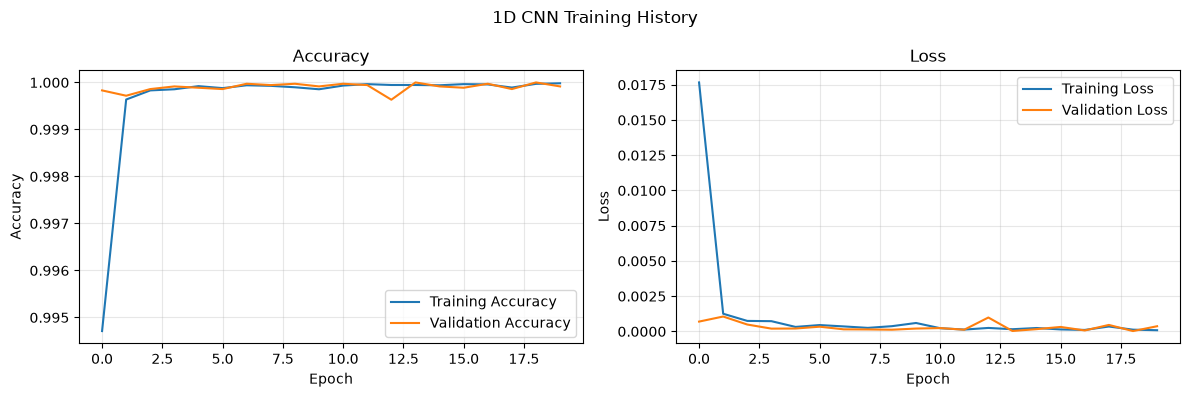

In [8]:
# Learning curve

plot_training_history(
    history,
    title="1D CNN Training History"
)

In [9]:
# Test prediction

y_prob = model.predict(
    X_test_cnn,
    batch_size=256
).ravel()

print("Prediction shape:", y_prob.shape)
print("First 10 probabilities:")
print(y_prob[:10])

139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Prediction shape: (35370,)
First 10 probabilities:
[1.000000e+00 1.000000e+00 1.000000e+00 1.000000e+00 1.000000e+00
 1.199533e-19 1.000000e+00 1.000000e+00 7.103421e-20 1.000000e+00]


In [10]:
cnn_metrics = calculate_metrics(
    y_test,
    y_prob
)

cnn_metrics

{'accuracy': 0.9998869098105739,
 'precision': 0.9999339498018494,
 'recall': 0.9998018755778629,
 'f1': 0.9998679083283799,
 'roc_auc': 0.9999999379677671}

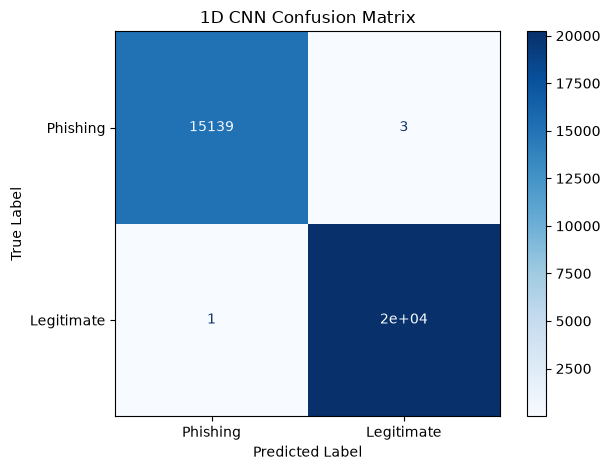

In [11]:
plot_confusion_matrix(
    y_test,
    y_prob,
    title="1D CNN Confusion Matrix"
)

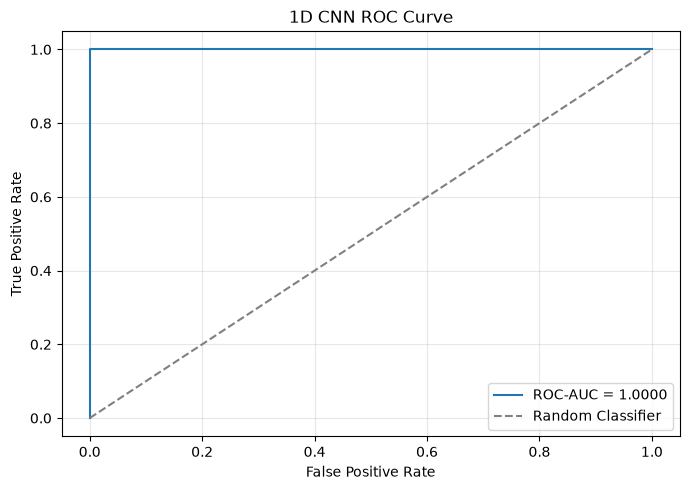

In [12]:
plot_roc_curve(
    y_test,
    y_prob,
    title="1D CNN ROC Curve"
)

In [13]:
y_pred = (y_prob >= 0.5).astype(int)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Phishing"],
        digits=4
    )
)

              precision    recall  f1-score   support

  Legitimate     0.9999    0.9998    0.9999     15142
    Phishing     0.9999    1.0000    0.9999     20228

    accuracy                         0.9999     35370
   macro avg     0.9999    0.9999    0.9999     35370
weighted avg     0.9999    0.9999    0.9999     35370



In [14]:
cnn_result = {
    "model": "1D CNN",
    "accuracy": cnn_metrics["accuracy"],
    "precision": cnn_metrics["precision"],
    "recall": cnn_metrics["recall"],
    "f1": cnn_metrics["f1"],
    "roc_auc": cnn_metrics["roc_auc"],
    "parameters": model.count_params(),
    "training_time_seconds": training_time,
    "epochs_trained": len(history.history["loss"])
}

cnn_result

{'model': '1D CNN',
 'accuracy': 0.9998869098105739,
 'precision': 0.9999339498018494,
 'recall': 0.9998018755778629,
 'f1': 0.9998679083283799,
 'roc_auc': 0.9999999379677671,
 'parameters': 51521,
 'training_time_seconds': 182.89935994148254,
 'epochs_trained': 20}

In [15]:
results_df = pd.DataFrame([cnn_result])

results_path = Path("../results/tables/cnn1d_results.csv")
results_path.parent.mkdir(parents=True, exist_ok=True)

results_df.to_csv(results_path, index=False)

print(f"Saved results to: {results_path}")

Saved results to: ..\results\tables\cnn1d_results.csv
